# Head Pose Estimation Benchmark — LivePortrait Head Pose Model

This notebook evaluates head pose estimation using the internal motion descriptor extracted from the **LivePortrait** pipeline. LivePortrait is a portrait animation framework that internally estimates head pose (yaw, pitch, roll) as part of its motion representation — these descriptors are repurposed here for head pose benchmarking without running the full animation pipeline.

**Reference repo:** [LivePortrait](https://github.com/KwaiVGI/LivePortrait)

To run this notebook, clone the LivePortrait repository and place this notebook in the root of that directory. Model weights and configuration files must be present as per the repo's setup instructions.

**Dataset:** FEI Face Database — 200 subjects × 11 pose images ranging from -90° to +90° yaw.

> **Note:** The monotonicity check in this notebook evaluates 10 positions (-90° to +90°, excluding the frontal 0° position), giving 9 steps per person and 1800 possible transitions total, rather than the 10 steps used in other notebooks.

## 1. Imports & Environment Setup

Imports the LivePortrait source modules alongside standard evaluation libraries:
- `src.live_portrait_pipeline` / `LivePortraitPipeline` — the main pipeline handling face cropping, landmark detection, and motion descriptor extraction
- `src.config` — `ArgumentConfig`, `InferenceConfig`, and `CropConfig` used to initialise the pipeline
- `src.utils.io` / `load_image_rgb` — image loading utility
- `tyro` — CLI argument parsing used by LivePortrait; initialised with empty args to run cleanly inside Jupyter
- `subprocess` — used to verify ffmpeg availability, which LivePortrait requires
- `numpy`, `cv2`, `matplotlib`, `seaborn`, `scipy.stats.trim_mean`, `tqdm` — standard data processing and evaluation utilities

The pipeline is configured for CPU inference in this notebook. GPU can be enabled by changing `device = "cpu"` to `"cuda"` if a compatible GPU is available.

In [ ]:


from __future__ import annotations

from collections import OrderedDict
import os
import os.path as osp
import cv2
import numpy as np
import tyro
import subprocess

from src.config.argument_config import ArgumentConfig
from src.config.inference_config import InferenceConfig
from src.config.crop_config import CropConfig

from src.utils.io import load_image_rgb
from src.live_portrait_pipeline import LivePortraitPipeline
import os
import os
from collections import defaultdict
from tqdm import tqdm  # Import tqdm for progress bars
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import trim_mean
import time



## 2. Utility Functions & Pipeline Initialisation

Defines several utility functions required for LivePortrait setup:

- `remove_ddp_dumplicate_key()` — strips the `module.` prefix from model state dict keys that arise when models are saved with DistributedDataParallel, ensuring compatibility when loading on a single device
- `make_abs_path()` — resolves paths relative to the working directory
- `partial_fields()` — filters a kwargs dictionary to only pass keys that exist as attributes on the target config class, allowing safe instantiation of `InferenceConfig` and `CropConfig` from the full `ArgumentConfig`
- `fast_check_ffmpeg()` — verifies ffmpeg is installed and accessible, raising an error if not
- `fast_check_args()` — validates that source and driving paths exist before running

The `LivePortraitPipeline` is then initialised with the resolved inference and crop configs.

In [2]:
def remove_ddp_dumplicate_key(state_dict):
    state_dict_new = OrderedDict()
    for key in state_dict.keys():
        state_dict_new[key.replace('module.', '')] = state_dict[key]
    return state_dict_new

def make_abs_path(fn):
    return osp.join(osp.dirname(osp.realpath("./")), fn)

device = "cpu"

def partial_fields(target_class, kwargs):
    return target_class(**{k: v for k, v in kwargs.items() if hasattr(target_class, k)})

def fast_check_ffmpeg():
    try:
        subprocess.run(["ffmpeg", "-version"], capture_output=True, check=True)
        return True
    except:
        return False


def fast_check_args(args: ArgumentConfig):
    if not osp.exists(args.source):
        raise FileNotFoundError(f"source info not found: {args.source}")
    if not osp.exists(args.driving):
        raise FileNotFoundError(f"driving info not found: {args.driving}")

tyro.extras.set_accent_color("bright_cyan")
# Under Jupyter, sys.argv contains ipykernel's -f <connection.json>; avoid parsing it as tyro flags.
args = tyro.cli(ArgumentConfig, args=[])

ffmpeg_dir = os.path.join(os.getcwd(), "ffmpeg")
if osp.exists(ffmpeg_dir):
    os.environ["PATH"] += (os.pathsep + ffmpeg_dir)

if not fast_check_ffmpeg():
    raise ImportError(
        "FFmpeg is not installed. Please install FFmpeg (including ffmpeg and ffprobe) before running this script. https://ffmpeg.org/download.html"
    )

fast_check_args(args)

# specify configs for inference
inference_cfg = partial_fields(InferenceConfig, args.__dict__)
crop_cfg = partial_fields(CropConfig, args.__dict__)

live_portrait_pipeline = LivePortraitPipeline(
    inference_cfg=inference_cfg,
    crop_cfg=crop_cfg
)

/home/sawaiz/Documents/Lab/In_Progress/Current/landmarks_analysis/4_livePortrait_rpy/src/utils/helper.py:170: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_

[07:54:07] Load appearance_feature_extractor from                                       ]8;id=800477;file:///home/sawaiz/Documents/Lab/In_Progress/Current/landmarks_analysis/4_livePortrait_rpy/src/live_portrait_wrapper.py\live_portrait_wrapper.py]8;;\:]8;id=402937;file:///home/sawaiz/Documents/Lab/In_Progress/Current/landmarks_analysis/4_livePortrait_rpy/src/live_portrait_wrapper.py#46\46]8;;\
           /home/sawaiz/Documents/Lab/In_Progress/Current/landmarks_analysis/4_livePort                            
           rait_rpy/pretrained_weights/liveportrait/base_models/appearance_feature_extr                            
           actor.pth done.                                                                                         

           Load motion_extractor from                                                   ]8;id=613415;file:///home/sawaiz/Documents/Lab/In_Progress/Current/landmarks_analysis/4_livePortrait_rpy/src/live_portrait_wrapper.py\live_portrait_wrapper.py]8;;\:]8;id=790495;file:///home/sawaiz/Documents/Lab/In_Progress/Current/landmarks_analysis/4_livePortrait_rpy/src/live_portrait_wrapper.py#49\49]8;;\
           /home/sawaiz/Documents/Lab/In_Progress/Current/landmarks_analysis/4_livePort                            
           rait_rpy/pretrained_weights/liveportrait/base_models/motion_extractor.pth                               
           done.                                                                                                   

[07:54:08] Load warping_module from                                                     ]8;id=747951;file:///home/sawaiz/Documents/Lab/In_Progress/Current/landmarks_analysis/4_livePortrait_rpy/src/live_portrait_wrapper.py\live_portrait_wrapper.py]8;;\:]8;id=371038;file:///home/sawaiz/Documents/Lab/In_Progress/Current/landmarks_analysis/4_livePortrait_rpy/src/live_portrait_wrapper.py#52\52]8;;\
           /home/sawaiz/Documents/Lab/In_Progress/Current/landmarks_analysis/4_livePort                            
           rait_rpy/pretrained_weights/liveportrait/base_models/warping_module.pth                                 
           done.                                                                                                   

[07:54:09] Load spade_generator from                                                    ]8;id=805250;file:///home/sawaiz/Documents/Lab/In_Progress/Current/landmarks_analysis/4_livePortrait_rpy/src/live_portrait_wrapper.py\live_portrait_wrapper.py]8;;\:]8;id=470367;file:///home/sawaiz/Documents/Lab/In_Progress/Current/landmarks_analysis/4_livePortrait_rpy/src/live_portrait_wrapper.py#55\55]8;;\
           /home/sawaiz/Documents/Lab/In_Progress/Current/landmarks_analysis/4_livePort                            
           rait_rpy/pretrained_weights/liveportrait/base_models/spade_generator.pth                                
           done.                                                                                                   

/home/sawaiz/Documents/Lab/In_Progress/Current/landmarks_analysis/4_livePortrait_rpy/src/utils/helper.py:145: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torc

           Load stitching_retargeting_module from                                       ]8;id=925315;file:///home/sawaiz/Documents/Lab/In_Progress/Current/landmarks_analysis/4_livePortrait_rpy/src/live_portrait_wrapper.py\live_portrait_wrapper.py]8;;\:]8;id=866900;file:///home/sawaiz/Documents/Lab/In_Progress/Current/landmarks_analysis/4_livePortrait_rpy/src/live_portrait_wrapper.py#59\59]8;;\
           /home/sawaiz/Documents/Lab/In_Progress/Current/landmarks_analysis/4_livePort                            
           rait_rpy/pretrained_weights/liveportrait/retargeting_models/stitching_retarg                            
           eting_module.pth done.                                                                                  

/home/sawaiz/.local/lib/python3.10/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:69: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


           FaceAnalysisDIY warmup time: 0.082s                                              ]8;id=316024;file:///home/sawaiz/Documents/Lab/In_Progress/Current/landmarks_analysis/4_livePortrait_rpy/src/utils/face_analysis_diy.py\face_analysis_diy.py]8;;\:]8;id=704707;file:///home/sawaiz/Documents/Lab/In_Progress/Current/landmarks_analysis/4_livePortrait_rpy/src/utils/face_analysis_diy.py#79\79]8;;\

           LandmarkRunner warmup time: 0.050s                                           ]8;id=288317;file:///home/sawaiz/Documents/Lab/In_Progress/Current/landmarks_analysis/4_livePortrait_rpy/src/utils/human_landmark_runner.py\human_landmark_runner.py]8;;\:]8;id=818108;file:///home/sawaiz/Documents/Lab/In_Progress/Current/landmarks_analysis/4_livePortrait_rpy/src/utils/human_landmark_runner.py#95\95]8;;\

## 3. Pose Extraction Pipeline — `get_descriptor_information()`

This function extracts yaw, pitch, and roll from a single image by running it through the LivePortrait motion descriptor pipeline — without performing any animation.

**Steps:**
1. **Image loading** — the image is loaded as RGB and wrapped in a single-frame list to match the video pipeline interface
2. **Face cropping & landmark detection** — `cropper.crop_driving_video()` detects the face, crops it, and extracts landmarks
3. **Resize** — the cropped face is resized to 256×256 as required by the motion network
4. **Ratio computation** — eye and lip ratios are computed from the landmarks, used internally by LivePortrait for expression control
5. **Motion template extraction** — `make_motion_template()` runs the image through the motion encoder and returns a dictionary containing the estimated yaw, pitch, and roll as tensors

The pose values are returned directly from the motion descriptor — these are the internal head pose representations LivePortrait uses to drive portrait animation, repurposed here for benchmarking.

In [3]:
def get_descriptor_information(img_path):
    #Part 2
    # flag_is_driving_video = False
    driving_img_rgb = load_image_rgb(img_path)
    output_fps = 25
    driving_rgb_lst = [driving_img_rgb]

    # Part 4.1 excluding 4.1.1
    ret_d = live_portrait_pipeline.cropper.crop_driving_video(driving_rgb_lst)
    driving_rgb_crop_lst, driving_lmk_crop_lst = ret_d['frame_crop_lst'], ret_d['lmk_crop_lst']
    driving_rgb_crop_256x256_lst = [cv2.resize(_, (256, 256)) for _ in driving_rgb_crop_lst]

    # Consistent block minus some dumping pkl logic
    c_d_eyes_lst, c_d_lip_lst = live_portrait_pipeline.live_portrait_wrapper.calc_ratio(driving_lmk_crop_lst)

    # save the motion template
    I_d_lst = live_portrait_pipeline.live_portrait_wrapper.prepare_videos(driving_rgb_crop_256x256_lst)
    driving_template_dct = live_portrait_pipeline.make_motion_template(I_d_lst, c_d_eyes_lst, c_d_lip_lst, output_fps=output_fps)

    return {
        "yaw": driving_template_dct.get("yaw"),
        "roll": driving_template_dct.get("roll"),
        "pitch": driving_template_dct.get("pitch"),
    }

## 4. Full Dataset Processing

Iterates over all 200 subjects and 11 pose positions, extracting pose descriptors from each image using the LivePortrait pipeline. Roll, pitch, and yaw tensors are moved from GPU/CPU tensors to Python floats before storage.

Results are accumulated in two structures: per-position angle lists for aggregate statistics, and a per-person dictionary for monotonicity evaluation. Missing files are handled via filename fallback. All 200 subjects are successfully processed across all 11 positions (n=200 for every position).

In [4]:
# Path to your dataset
dataset_path = "/home/sawaiz/Documents/fyp phase 3/landmark_analysis/dataset/fei dataset"

# Define the ordered positions with their corresponding position codes
ordered_positions = ['90', '75', '60', '45', '30', '-30', '-45', '-60', '-75', '-90', '0']
position_map = {f"{i+1:02d}": pos_label for i, pos_label in enumerate(ordered_positions)}

import time

# Dicts to accumulate roll, pitch, and yaw angles for each position label
yaw_angles_by_position = defaultdict(list)
pitch_angles_by_position = defaultdict(list)
roll_angles_by_position = defaultdict(list)

person_ids = list(range(1, 201))  # assuming 1 to 200
positions = list(range(1, 12))    # image positions 01 to 11

# Store per-person ALL pose angles for every position
person_pose = defaultdict(dict) # person_pose[person_id][position_label] = (roll, pitch, yaw)

image_count = 0
start_time = time.time()

for person_id in tqdm(person_ids, desc="Processing Persons"):
    person_prefix = str(person_id)
    for pos_idx, pos in enumerate(positions):
        pos_str = f"{pos:02d}"  # zero-padded position index
        pos_label = ordered_positions[pos_idx]
        img_name = f"{person_prefix}-{pos_str}.jpg"
        img_path = os.path.join(dataset_path, img_name)
        if not os.path.isfile(img_path):
            img_name = f"{person_prefix}-{pos_str}.JPG"
            img_path = os.path.join(dataset_path, img_name)
        if not os.path.isfile(img_path):
            continue  # skip if file doesn't exist

        results = get_descriptor_information(img_path)
        roll = float(results["roll"].cpu())
        pitch = float(results["pitch"].cpu())
        yaw = float(results["yaw"].cpu())

        roll_angles_by_position[pos_label].append(roll)
        pitch_angles_by_position[pos_label].append(pitch)
        yaw_angles_by_position[pos_label].append(yaw)
        person_pose[person_id][pos_label] = (roll, pitch, yaw)
        image_count += 1

end_time = time.time()
avg_time_per_image = (end_time - start_time) / image_count if image_count > 0 else float('nan')
print(f"Average time taken to process 1 image: {avg_time_per_image:.4f} seconds")

Processing Persons:  15%|█▌        | 30/200 [01:08<06:11,  2.19s/it]

[07:55:20] More than one face detected in the driving frame_0, only pick one face by rule            ]8;id=236221;file:///home/sawaiz/Documents/Lab/In_Progress/Current/landmarks_analysis/4_livePortrait_rpy/src/utils/cropper.py\cropper.py]8;;\:]8;id=19513;file:///home/sawaiz/Documents/Lab/In_Progress/Current/landmarks_analysis/4_livePortrait_rpy/src/utils/cropper.py#242\242]8;;\
           large-small.                                                                                            

Processing Persons:  19%|█▉        | 38/200 [01:28<06:45,  2.50s/it]

[07:55:40] More than one face detected in the driving frame_0, only pick one face by rule            ]8;id=47116;file:///home/sawaiz/Documents/Lab/In_Progress/Current/landmarks_analysis/4_livePortrait_rpy/src/utils/cropper.py\cropper.py]8;;\:]8;id=608034;file:///home/sawaiz/Documents/Lab/In_Progress/Current/landmarks_analysis/4_livePortrait_rpy/src/utils/cropper.py#242\242]8;;\
           large-small.                                                                                            

           More than one face detected in the driving frame_0, only pick one face by rule            ]8;id=530932;file:///home/sawaiz/Documents/Lab/In_Progress/Current/landmarks_analysis/4_livePortrait_rpy/src/utils/cropper.py\cropper.py]8;;\:]8;id=102383;file:///home/sawaiz/Documents/Lab/In_Progress/Current/landmarks_analysis/4_livePortrait_rpy/src/utils/cropper.py#242\242]8;;\
           large-small.                                                                                            

...

[08:00:20] More than one face detected in the driving frame_0, only pick one face by rule            ]8;id=973294;file:///home/sawaiz/Documents/Lab/In_Progress/Current/landmarks_analysis/4_livePortrait_rpy/src/utils/cropper.py\cropper.py]8;;\:]8;id=148978;file:///home/sawaiz/Documents/Lab/In_Progress/Current/landmarks_analysis/4_livePortrait_rpy/src/utils/cropper.py#242\242]8;;\
           large-small.                                                                                            

Processing Persons:  86%|████████▋ | 173/200 [06:37<01:01,  2.27s/it]

[08:00:48] More than one face detected in the driving frame_0, only pick one face by rule            ]8;id=312180;file:///home/sawaiz/Documents/Lab/In_Progress/Current/landmarks_analysis/4_livePortrait_rpy/src/utils/cropper.py\cropper.py]8;;\:]8;id=671073;file:///home/sawaiz/Documents/Lab/In_Progress/Current/landmarks_analysis/4_livePortrait_rpy/src/utils/cropper.py#242\242]8;;\
           large-small.                                                                                            

Processing Persons: 100%|██████████| 200/200 [07:37<00:00,  2.29s/it]

Average time taken to process 1 image: 0.2081 seconds


## 5. Evaluation Metric 1 — Monotonic Yaw Increase Check

For a head pose estimator to be considered reliable, predicted yaw values should **strictly increase** as the head rotates from -90° to +90°. Since the FEI dataset captures subjects at physically ordered pose angles, any non-increasing transition indicates the model failed to track the angular change between those two positions.

**Metric:** Count of broken (non-increasing) transitions out of 1800 possible (200 persons × 9 consecutive steps across the 10 non-frontal positions).

> **Note:** The frontal 0° position is excluded from the monotonicity check in this notebook, reducing the sequence to 10 positions and 9 steps per person.

### Result

The LivePortrait motion descriptor achieves **39 broken transitions out of 1800**, affecting **34 out of 200 subjects** — a strong result that places it second only to L2CS in this benchmark. Critically, the character of the failures is very different from the catastrophic breakdowns seen in FacePose_pytorch or MTCNN + PnP. Every single break is a **small-gap near-boundary error**: the largest gap in the entire output is -8.21° (Person 030 at `-30°→0°`), and the vast majority are under 5°. There are no sign flips, no collapses to near-zero, and no reversals spanning more than ~8°. The most common failure point is the `-30°→0°` transition, which accounts for the majority of breaks — a region where predicted yaw values are compressed near zero and small absolute errors can cause ordering violations. A secondary cluster appears at `45°→60°` on the positive side, with gaps so small (0.06°–1.25°) they are effectively floating-point noise rather than meaningful estimation failures. This pattern strongly suggests the LivePortrait motion descriptor has a **compression zone near the frontal plane** where angular sensitivity is reduced, but performs robustly at all other angles including the extreme ±90° positions where other methods typically fail most severely.

In [5]:
positions_order = ['-90', '-75', '-60', '-45', '-30', '0', '30', '45', '60', '75', '90']
breaks_info = []  # (person_id, break_index, (previous_yaw, current_yaw))
total_persons_checked = 0
total_gap_instances = 0
total_non_increasing = 0
gaps = []

# To track all gaps per person with a break
person_break_gaps = {}  # person_id -> list of gaps for that person

for person_id in sorted(person_pose.keys()):
    yaws = [person_pose[person_id][pos][2] for pos in positions_order if pos in person_pose[person_id]]
    # Only check if all 10 positions present
    if any(yaw is None for yaw in yaws):
        continue
    total_persons_checked += 1
    person_gaps = []
    for i in range(len(yaws) - 1):
        if yaws[i] >= yaws[i + 1]:
            # Record the first break: index, and values at break
            breaks_info.append((person_id, positions_order[i], yaws[i], positions_order[i+1], yaws[i+1]))
            # Calculate the gap (difference between previous_yaw and current_yaw at break)
            gap = yaws[i+1] - yaws[i]  # should be negative or zero
            gaps.append(gap)
            person_gaps.append(gap)
            total_gap_instances += 1

    if person_gaps:
        total_non_increasing += 1
        person_break_gaps[person_id] = person_gaps

if breaks_info:
    print("Persons and positions where yaw does NOT strictly increase from 01 to 10:")
    for person_id, pos1, yaw1, pos2, yaw2 in breaks_info:
        gap_this_break = yaw2 - yaw1

        print(f" Person {person_id:03d}: Break at {pos1}→{pos2} | yaw: {yaw1:.2f}° → {yaw2:.2f}° | gap: {gap_this_break:.2f}°")
    print(f"\nTotal persons with non-increasing yaw: {total_non_increasing} out of {total_persons_checked}")
    print(f"\nTotal number of non-increasing transitions detected (gap instances): {total_gap_instances} out of {total_persons_checked * (len(positions_order)-1)} possible transitions "
          f"(200 persons × 10 steps = {200*10} transitions)")

else:
    print("All persons have strictly increasing yaw from 01 to 10.")
    print(f"\nTotal persons checked: {total_persons_checked}")

Persons and positions where yaw does NOT strictly increase from 01 to 10:
 Person 002: Break at -30→0 | yaw: -1.78° → -2.85° | gap: -1.06°
 Person 011: Break at -45→-30 | yaw: 3.31° → -0.36° | gap: -3.67°
 Person 011: Break at -30→0 | yaw: -0.36° → -3.77° | gap: -3.42°
 Person 023: Break at -30→0 | yaw: -0.87° → -1.51° | gap: -0.64°
 Person 027: Break at -30→0 | yaw: -1.21° → -5.84° | gap: -4.63°
 Person 030: Break at -30→0 | yaw: 3.51° → -4.71° | gap: -8.21°
 Person 039: Break at -30→0 | yaw: 2.28° → 0.07° | gap: -2.21°
 Person 041: Break at -60→-45 | yaw: -19.22° → -24.38° | gap: -5.16°
 Person 047: Break at -30→0 | yaw: -1.02° → -2.63° | gap: -1.61°
 Person 048: Break at -30→0 | yaw: 0.55° → 0.28° | gap: -0.26°
 Person 055: Break at 45→60 | yaw: 27.07° → 26.89° | gap: -0.18°
 Person 056: Break at -30→0 | yaw: -1.51° → -1.61° | gap: -0.10°
 Person 057: Break at 45→60 | yaw: 24.24° → 24.18° | gap: -0.06°
 Person 059: Break at -30→0 | yaw: 3.89° → -0.41° | gap: -4.31°
 Person 060: Brea

## 6. Evaluation Metric 2 — Trimmed Mean Yaw, Pitch & Roll per Position

Computes the **10% trimmed mean** of predicted roll, pitch, and yaw across all 200 subjects at each of the 11 ground truth positions.

This metric evaluates:
1. **Calibration** — does the predicted yaw trend in the right direction and reach a plausible magnitude at each position?
2. **Stability** — do pitch and roll remain near zero across positions where they should theoretically be constant?

### Result

The trimmed mean yaw values show a clean monotonic progression across all 11 positions, with the frontal position returning -1.25° — an excellent near-zero result. However, a pronounced **compression bias** is visible throughout: at ±90° the model predicts -62.54° and 59.90° respectively, and at ±75° only -36.31° and 39.55°. The underestimation grows with angle, which is consistent with how motion encoders trained primarily for animation tasks tend to represent pose — small deviations from frontal are encoded with high sensitivity, while large rotations are increasingly compressed in the latent space. Notably, the positive side reaches 59.90° at +90° while the negative side reaches -62.54°, a slightly more symmetric result than most other methods in this benchmark. Pitch is exceptionally stable across the mid-range positions, staying within ±1° from -60° to +60°, but dips to -6.12° at -90° and -7.36° at +90° — a modest coupling with extreme yaw that is far smaller than the pitch instability seen in the PnP-based methods. Roll stays near zero across frontal and mid-range poses but grows to -6.11° at +90° and 2.82° at -90°, showing a slight asymmetric roll coupling at extreme profile angles. Overall this is one of the cleaner calibration profiles in the benchmark, with pitch and roll stability being a particular strength.

In [6]:
ordered_positions = ['-90', '-75', '-60', '-45', '-30', '0', '30', '45', '60', '75', '90']
avg_yaw_by_position = {}
avg_pitch_by_position = {}
avg_roll_by_position = {}

# Use a trimmed mean (e.g., trim 10% at each end)
trim_fraction = 0.1

for pos_str in tqdm(ordered_positions, desc="Calculating averages"):
    yaws = yaw_angles_by_position[pos_str]
    pitches = pitch_angles_by_position[pos_str]
    rolls = roll_angles_by_position[pos_str]
    if yaws:
        avg_yaw = trim_mean(yaws, proportiontocut=trim_fraction)
        avg_pitch = trim_mean(pitches, proportiontocut=trim_fraction) if pitches else float('nan')
        avg_roll = trim_mean(rolls, proportiontocut=trim_fraction) if rolls else float('nan')
        avg_yaw_by_position[pos_str] = avg_yaw
        avg_pitch_by_position[pos_str] = avg_pitch
        avg_roll_by_position[pos_str] = avg_roll
        print(f"Position {pos_str}: Trimmed Avg Yaw = {avg_yaw:.2f}°, Pitch = {avg_pitch:.2f}°, Roll = {avg_roll:.2f}° (n={len(yaws)})")
    else:
        print(f"Position {pos_str}: No valid faces found.")


Calculating averages: 100%|██████████| 11/11 [00:00<00:00, 3583.48it/s]

Position -90: Trimmed Avg Yaw = -62.54°, Pitch = -6.12°, Roll = 2.82° (n=200)
Position -75: Trimmed Avg Yaw = -36.31°, Pitch = -1.71°, Roll = 0.80° (n=200)
Position -60: Trimmed Avg Yaw = -26.68°, Pitch = -1.23°, Roll = 0.57° (n=200)
Position -45: Trimmed Avg Yaw = -19.78°, Pitch = -1.10°, Roll = 0.22° (n=200)
Position -30: Trimmed Avg Yaw = -7.55°, Pitch = -0.14°, Roll = -0.28° (n=200)
Position 0: Trimmed Avg Yaw = -1.25°, Pitch = -0.23°, Roll = -0.52° (n=200)
Position 30: Trimmed Avg Yaw = 10.38°, Pitch = 0.35°, Roll = -1.37° (n=200)
Position 45: Trimmed Avg Yaw = 21.94°, Pitch = 0.24°, Roll = -2.10° (n=200)
Position 60: Trimmed Avg Yaw = 27.29°, Pitch = -0.30°, Roll = -2.20° (n=200)
Position 75: Trimmed Avg Yaw = 39.55°, Pitch = -1.96°, Roll = -2.92° (n=200)
Position 90: Trimmed Avg Yaw = 59.90°, Pitch = -7.36°, Roll = -6.11° (n=200)


## 7. Evaluation Metric 3 — Yaw Distribution per Position

Plots the full distribution of predicted yaw values across all 200 subjects for each of the 11 ground truth positions. Each subplot shows a histogram with a KDE overlay, along with vertical lines marking the raw mean and 10% trimmed mean.

### Result

The distribution plots confirm LivePortrait as one of the most consistent methods in this benchmark. Distributions are **clean, unimodal, and well-formed** at every position, with raw mean and trimmed mean lines nearly coincident throughout — a clear sign of minimal outliers. Standard deviations range from 3.30° at the frontal position to 7.12° at -75°, with all mid-range positions (±30° through ±60°) sitting comfortably in the 4–6° range. There are no bimodal distributions, no sign-flip clusters, and no position-specific collapses of the kind seen in other methods. The -90° and +90° distributions are the widest (std ~6.7°) but remain unimodal and clearly positioned on the correct side of zero, confirming the model handles extreme angles gracefully. A notable feature is the consistent **slight left shift** across all positions — the compression bias identified in the trimmed mean table is visible here as distributions centred somewhat below the ground truth target at each position. The frontal (0°) distribution is tight (std=3.30°) and centred at -1.27°, the best calibration performance of any method with full roll/pitch/yaw output. Compared to L2CS, LivePortrait's distributions are slightly wider but offer the advantage of providing a genuine roll estimate rather than a hardcoded zero.

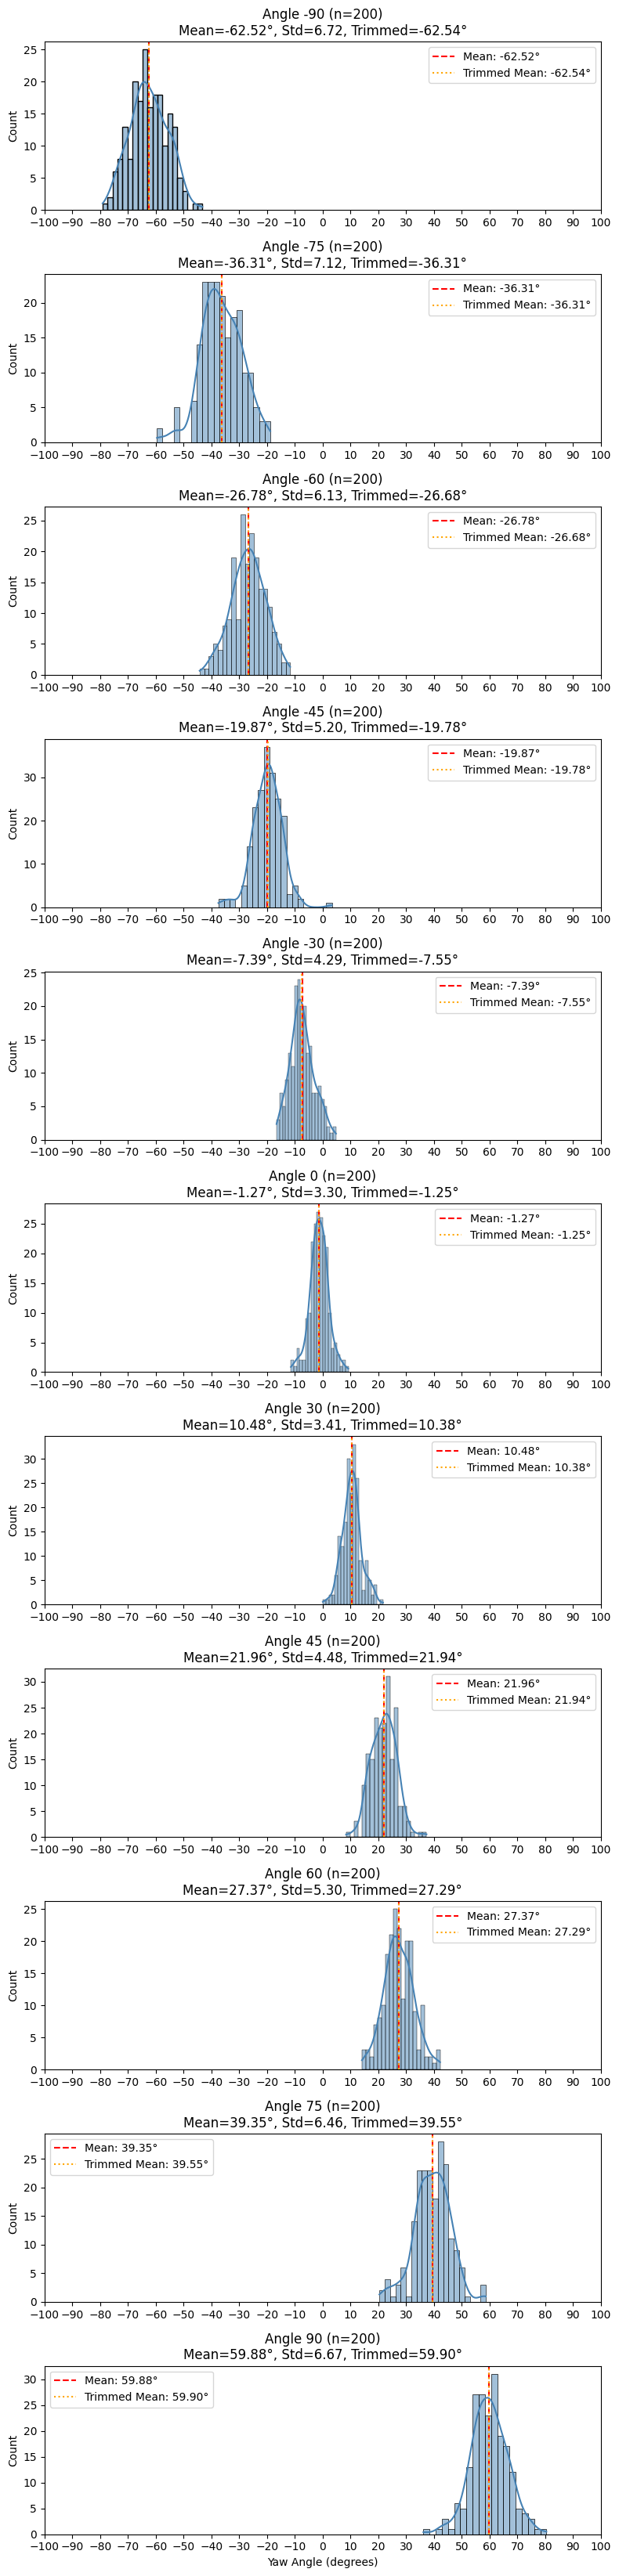

In [7]:
positions_order = ['-90', '-75', '-60', '-45', '-30', '0', '30', '45', '60', '75', '90']

# Prepare for plotting
positions = sorted(yaw_angles_by_position.keys())

fig, axes = plt.subplots(len(positions), 1, figsize=(8, 3 * len(positions)), sharex=True)

if len(positions) == 1:
    axes = [axes]  # in case only one position

for idx, pos_str in enumerate(positions_order):
    yaws = yaw_angles_by_position[pos_str]
    ax = axes[idx]
    if yaws:
        sns.histplot(yaws, bins=20, kde=True, ax=ax, color='steelblue')
        mean = np.mean(yaws)
        trimmed = trim_mean(yaws, proportiontocut=0.1)
        std = np.std(yaws)
        n = len(yaws)
        ax.axvline(mean, color='red', linestyle='--', label=f"Mean: {mean:.2f}°")
        ax.axvline(trimmed, color='orange', linestyle=':', label=f"Trimmed Mean: {trimmed:.2f}°")
        ax.set_title(f"Angle {pos_str} (n={n})\nMean={mean:.2f}°, Std={std:.2f}, Trimmed={trimmed:.2f}°")

        # Set the x-axis limits from -90 to 90 as requested
        ax.set_xlim(-100, 100)

        # Set x-axis ticks every 10 degrees
        ax.set_xticks(np.arange(-100, 101, 10))

        # Ensures y axis shows tick labels for each plot clearly
        ax.tick_params(axis='y', which='both', labelleft=True, left=True)
        ax.yaxis.set_tick_params(labelleft=True)
        ax.set_ylabel("Count")

        # Ensure x-axis and y-axis tick labels are visible and not overlapped
        ax.tick_params(axis='x', which='both', labelbottom=True, bottom=True, labelsize=10, rotation=0)
        ax.xaxis.set_tick_params(labelbottom=True)
        for label in ax.get_xticklabels():
            label.set_visible(True)
            label.set_fontsize(10)
            label.set_rotation(0)

        ax.legend()
        
    else:
        ax.set_title(f"Position {pos_str}: No valid data")
        ax.axis('off')

    # Set x-axis label for every axes (even for 'off' axes for consistency)
    ax.set_xlabel("Yaw Angle (degrees)")

# Redraw to ensure all ticks and labels are correctly applied
plt.tight_layout()
plt.show()